The ``aa.plot_rank()`` function gives a per-protein rank scatter: each protein's maximum prediction score is plotted against its rank (highest score first), colored by group (e.g. substrate / hold-out / non-substrate), with optional threshold lines for the deployment caller. It is the single most useful sanity check for a deployed per-protein predictor and pairs with the numeric metrics in ``aa.comp_per_protein_ap`` / ``aa.comp_detection_metrics``.

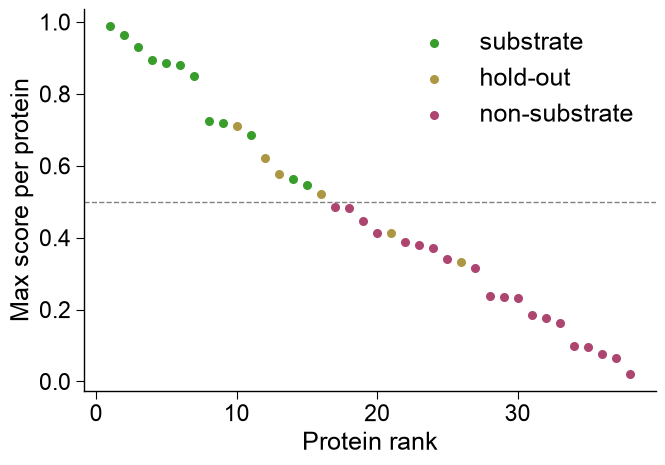

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import aaanalysis as aa

aa.plot_settings()
rng = np.random.default_rng(42)
df_rank = pd.DataFrame({
    "score": np.concatenate([rng.uniform(0.5, 1.0, 12),
                              rng.uniform(0.3, 0.8, 6),
                              rng.uniform(0.0, 0.5, 20)]),
    "group": ["substrate"] * 12 + ["hold-out"] * 6 + ["non-substrate"] * 20,
})
fig, ax = aa.plot_rank(df_rank=df_rank, threshold=0.5)
plt.tight_layout()
plt.show()

**Further parameters.** ``plot_rank`` also accepts: ``col_score`` — Column with the per-protein score used for ranking (descending) on the y-axis; ``col_group`` — Column with the per-protein group label used for coloring; ``group_order`` — Order in which groups are colored / drawn; ``dict_color`` — Mapping ``group -> color`` (overrides the canonical defaults); ``figsize`` — Figure size when ``ax`` is ``None``; ``marker_size`` — Scatter marker size; ``xlabel``; ``ylabel``; ``fontsize_labels`` — Font size for the axis labels (matplotlib default if ``None``).

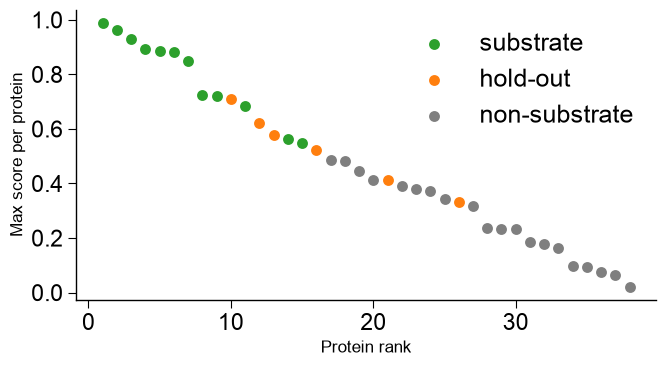

In [2]:
# Further parameters: name the score/group columns, fix the group order and colors,
# and tune figure size, marker size, axis labels, and the label font size.
group_order = ["substrate", "hold-out", "non-substrate"]
dict_color = {"substrate": "tab:green", "hold-out": "tab:orange", "non-substrate": "tab:gray"}
fig, ax = aa.plot_rank(df_rank=df_rank,
                       col_score="score",
                       col_group="group",
                       group_order=group_order,
                       dict_color=dict_color,
                       figsize=(7, 4),
                       marker_size=40,
                       xlabel="Protein rank",
                       ylabel="Max score per protein",
                       fontsize_labels=12)
plt.tight_layout()
plt.show()